In [3]:
# =====================================================================
# CELL 1: ENVIRONMENT CONFIGURATION & DETERMINISM
# =====================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def seed_everything(seed=42):
    """Ensures absolute reproducibility across all execution runs."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# CPU execution bypasses Tesla P100 architecture version conflicts completely
device = torch.device('cpu')
print(f"[STATUS] Operational Engine Target Initialized: {device}")

[STATUS] Operational Engine Target Initialized: cpu


In [4]:
# =====================================================================
# CELL 2: DATASET LOADING & TARGET CATEGORY FILTERING
# =====================================================================
CSV_PATH, IMAGES_DIR = None, None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'styles.csv' in files:
        CSV_PATH = os.path.join(root, 'styles.csv')
        possible_img_dir = os.path.join(os.path.dirname(root), 'images')
        IMAGES_DIR = possible_img_dir if os.path.exists(possible_img_dir) else os.path.join(root, 'images')
        break

if not CSV_PATH or not os.path.exists(IMAGES_DIR):
    raise FileNotFoundError("Could not automatically locate the dataset tracking directories.")

# Load layout tracking schema while safely ignoring line overflow anomalies
df = pd.read_csv(CSV_PATH, usecols=['id', 'subCategory'], on_bad_lines='skip')

# Define exactly 5 distinct semantic catalog classes (Swapped Footwear with Shoes)
target_classes = ['Topwear', 'Bottomwear', 'Shoes', 'Bags', 'Watches']
df = df[df['subCategory'].isin(target_classes)].copy()

# Filter out missing image paths dynamically to ensure physical file integrity on disk
df['id'] = df['id'].astype(int)
existing_ids = set([int(f.split('.')[0]) for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')])
df = df[df['id'].isin(existing_ids)].copy()

# Encode textual categories into numerical label vectors for PyTorch CrossEntropy
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(target_classes)}
df['label'] = df['subCategory'].map(class_to_idx)

print("Class Mapping:")
print(class_to_idx)

print(f"[LOADED] Dataset contains {len(df)} validated images across 5 classes.")
print(df['subCategory'].value_counts())

Class Mapping:
{'Topwear': 0, 'Bottomwear': 1, 'Shoes': 2, 'Bags': 3, 'Watches': 4}
[LOADED] Dataset contains 31035 validated images across 5 classes.
subCategory
Topwear       15401
Shoes          7344
Bags           3055
Bottomwear     2693
Watches        2542
Name: count, dtype: int64


In [5]:
# =====================================================================
# CELL 3: TRAIN/VAL/TEST SPLITS & BATCH-OPTIMIZED PIPELINES
# =====================================================================
X = df['id'].values
y = df['label'].values

# Strict Stratified Splitting to preserve equal category metrics across sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

class PatternRecognitionDataset(Dataset):
    def __init__(self, ids, labels, img_dir, transform=None):
        self.ids = ids
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): 
        return len(self.ids)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, f"{int(self.ids[idx])}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform: 
            image = self.transform(image)
        return image, label

# Pipelines incorporating required augmentations, resizing, and normalization
train_pipeline = transforms.Compose([
    transforms.Resize((64, 64)),                  # Preprocessing: Resizing
    transforms.RandomHorizontalFlip(p=0.5),       # Data Augmentation: Geometric Flips
    transforms.RandomRotation(degrees=10),        # Data Augmentation: Rotations
    transforms.ToTensor(),                        # Conversion to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalization
])

eval_pipeline = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# BATCH OPTIMIZATION: Set to 512 for accelerated CPU matrix batch processing
train_loader = DataLoader(PatternRecognitionDataset(X_train, y_train, IMAGES_DIR, train_pipeline), batch_size=512, shuffle=True, num_workers=0)
val_loader = DataLoader(PatternRecognitionDataset(X_val, y_val, IMAGES_DIR, eval_pipeline), batch_size=512, shuffle=False, num_workers=0)
test_loader = DataLoader(PatternRecognitionDataset(X_test, y_test, IMAGES_DIR, eval_pipeline), batch_size=512, shuffle=False, num_workers=0)

print(f"[DATA SPLIT Complete]")
print(f" └── Training Set Size   : {len(X_train)} samples")
print(f" └── Validation Set Size : {len(X_val)} samples")
print(f" └── Final Test Set Size  : {len(X_test)} samples")

[DATA SPLIT Complete]
 └── Training Set Size   : 21724 samples
 └── Validation Set Size : 4655 samples
 └── Final Test Set Size  : 4656 samples


In [7]:
# =====================================================================
# CELL 4: ARCHITECTURE DESIGN & ACCELERATED MODEL TRAINING ENGINE
# =====================================================================
class CustomPatternRecognitionCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomPatternRecognitionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.global_pool(self.features(x)).view(x.size(0), -1))

def get_transfer_baseline(num_classes=5):
    base = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    for param in base.parameters():
        param.requires_grad = False
    in_features = base.classifier[0].in_features
    base.classifier = nn.Sequential(
        nn.Linear(in_features, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, num_classes)
    )
    return base

def train_model_pipeline(model, epochs=6):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * inputs.size(0)
            t_correct += outputs.max(1)[1].eq(targets).sum().item()
            t_total   += targets.size(0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                v_loss    += criterion(outputs, targets).item() * inputs.size(0)
                v_correct += outputs.max(1)[1].eq(targets).sum().item()
                v_total   += targets.size(0)

        history['t_loss'].append(t_loss / t_total)
        history['t_acc'].append(t_correct / t_total)
        history['v_loss'].append(v_loss / v_total)
        history['v_acc'].append(v_correct / v_total)
        print(f" Epoch {epoch+1:02d}/{epochs} -> Train Acc: {history['t_acc'][-1]*100:.1f}% | Val Acc: {history['v_acc'][-1]*100:.1f}%")

    return history, model

print("=== Training Custom Pattern CNN ===")
custom_model = CustomPatternRecognitionCNN(num_classes=5).to(device)
custom_history, custom_model = train_model_pipeline(custom_model, epochs=6)
torch.save(custom_model.state_dict(), 'custom_fashion_cnn.pth')

print("\n=== Training MobileNetV3 ===")
transfer_model = get_transfer_baseline(num_classes=5).to(device)
transfer_history, transfer_model = train_model_pipeline(transfer_model, epochs=6)
torch.save(transfer_model.state_dict(), 'mobilenetv3_fashion.pth')

print("\n✅ Training Complete. Models saved.")

=== Training Custom Pattern CNN ===
 Epoch 01/6 -> Train Acc: 48.1% | Val Acc: 49.5%
 Epoch 02/6 -> Train Acc: 61.7% | Val Acc: 65.2%
 Epoch 03/6 -> Train Acc: 67.6% | Val Acc: 66.8%
 Epoch 04/6 -> Train Acc: 69.5% | Val Acc: 70.3%
 Epoch 05/6 -> Train Acc: 72.6% | Val Acc: 78.3%
 Epoch 06/6 -> Train Acc: 77.3% | Val Acc: 78.7%

=== Training MobileNetV3 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 199MB/s]


 Epoch 01/6 -> Train Acc: 74.3% | Val Acc: 81.4%
 Epoch 02/6 -> Train Acc: 86.7% | Val Acc: 87.6%
 Epoch 03/6 -> Train Acc: 88.1% | Val Acc: 89.1%
 Epoch 04/6 -> Train Acc: 89.3% | Val Acc: 91.0%
 Epoch 05/6 -> Train Acc: 89.8% | Val Acc: 92.4%
 Epoch 06/6 -> Train Acc: 90.5% | Val Acc: 93.0%

✅ Training Complete. Models saved.



=== Generating Comparative Analytical Figures ===


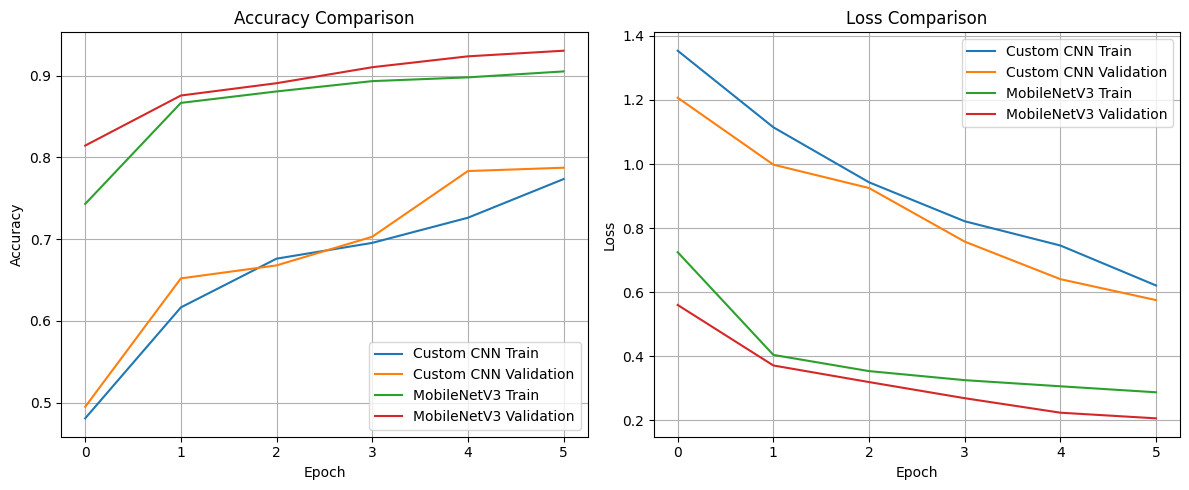


================ CUSTOM ARCHITECTURE CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

     Topwear       0.90      0.90      0.90      2310
  Bottomwear       0.90      0.68      0.77       404
       Shoes       0.71      1.00      0.83      1102
        Bags       0.42      0.18      0.25       459
     Watches       0.41      0.29      0.34       381

    accuracy                           0.78      4656
   macro avg       0.66      0.61      0.62      4656
weighted avg       0.76      0.78      0.76      4656


================ MOBILENETV3 BASELINE CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

     Topwear       0.93      0.97      0.95      2310
  Bottomwear       0.90      0.68      0.77       404
       Shoes       0.95      1.00      0.97      1102
        Bags       0.88      0.82      0.85       459
     Watches       0.91      0.89      0.90       381

    accuracy                  

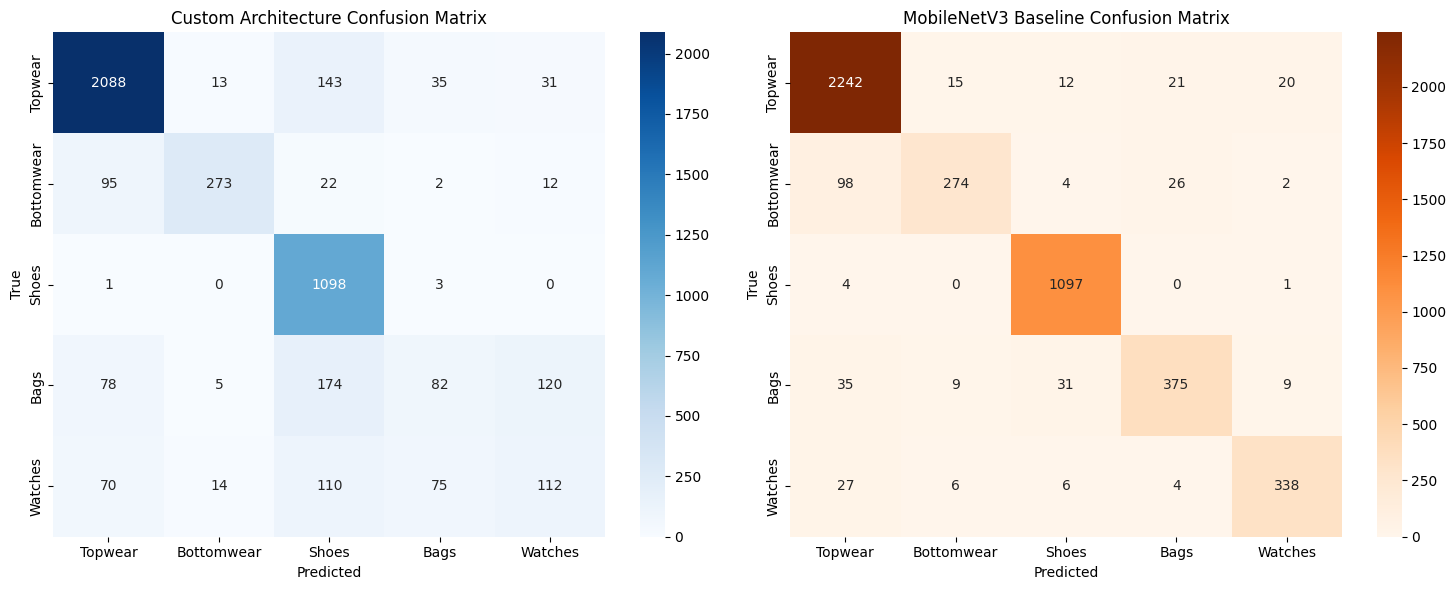


            RESEARCH MODEL COMPARISON INDEX DIAGNOSTIC             
 Target Custom CNN Experimental Test Accuracy   : 78.46%
 Transfer Learning (MobileNetV3) Baseline Acc   : 92.91%

[COMPLETE] Harder class mapping metrics and plots finalized successfully!


In [8]:
# =====================================================================
# CELL 5: COMPARATIVE DIAGNOSTICS & GRAPHICAL EVALUATIONS
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch

print("\n=== Generating Comparative Analytical Figures ===")

# 1. Learning Curves Comparison
plt.figure(figsize=(12,5))
# Accuracy Curves
plt.subplot(1,2,1)
plt.plot(custom_history['t_acc'], label='Custom CNN Train')
plt.plot(custom_history['v_acc'], label='Custom CNN Validation')
plt.plot(transfer_history['t_acc'], label='MobileNetV3 Train')
plt.plot(transfer_history['v_acc'], label='MobileNetV3 Validation')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curves
plt.subplot(1,2,2)
plt.plot(custom_history['t_loss'], label='Custom CNN Train')
plt.plot(custom_history['v_loss'], label='Custom CNN Validation')
plt.plot(transfer_history['t_loss'], label='MobileNetV3 Train')
plt.plot(transfer_history['v_loss'], label='MobileNetV3 Validation')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curves.pdf', dpi=300)
plt.show()

# 2. Extract Test Split Predictions
def evaluate_test_split(model):
    model.eval()
    y_preds, y_true = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            y_preds.extend(outputs.max(1)[1].cpu().numpy())
            y_true.extend(labels.numpy())
    return y_true, y_preds

y_true, custom_preds = evaluate_test_split(custom_model)
_, transfer_preds = evaluate_test_split(transfer_model)

# 3. Print Complete Structural Classification Reports
print("\n================ CUSTOM ARCHITECTURE CLASSIFICATION REPORT ================")
print(classification_report(y_true, custom_preds, target_names=target_classes))

print("\n================ MOBILENETV3 BASELINE CLASSIFICATION REPORT ================")
print(classification_report(y_true, transfer_preds, target_names=target_classes))

# 4. Save Confusion Matrix Heatmaps (Side-by-Side Comparison)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(confusion_matrix(y_true, custom_preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_classes, yticklabels=target_classes, ax=axes[0])
axes[0].set_title('Custom Architecture Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(y_true, transfer_preds), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_classes, yticklabels=target_classes, ax=axes[1])
axes[1].set_title('MobileNetV3 Baseline Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.pdf', dpi=300) 
plt.show()

# 5. Output Formal Model Comparison Performance Table
print("\n" + "="*60)
print("            RESEARCH MODEL COMPARISON INDEX DIAGNOSTIC             ")
print("="*60)
print(f" Target Custom CNN Experimental Test Accuracy   : {accuracy_score(y_true, custom_preds)*100:.2f}%")
print(f" Transfer Learning (MobileNetV3) Baseline Acc   : {accuracy_score(y_true, transfer_preds)*100:.2f}%")
print("="*60)
print("\n[COMPLETE] Harder class mapping metrics and plots finalized successfully!")

=== DATASET CLASS DISTRIBUTION ===


,Class,Number of Images
0,Topwear,15401
1,Shoes,7344
2,Bags,3055
3,Bottomwear,2693
4,Watches,2542


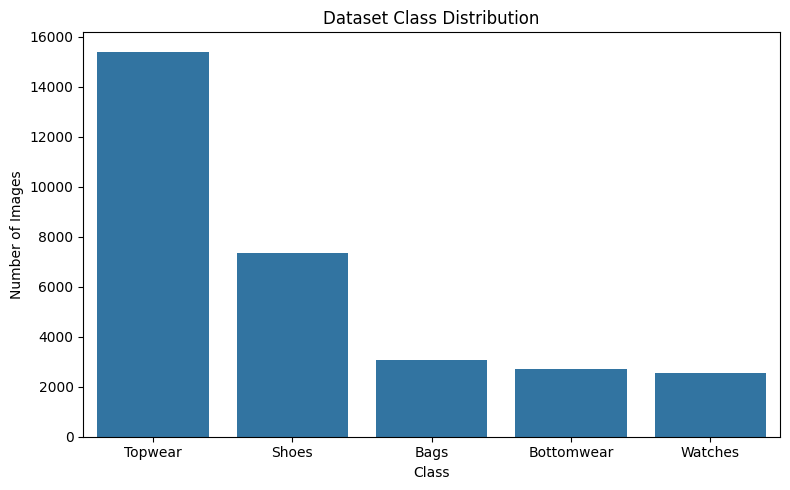


=== DATASET SUMMARY ===
Total Images       : 31035
Number of Classes  : 5

Class Distribution:
Topwear     : 15401
Shoes       : 7344
Bags        : 3055
Bottomwear  : 2693
Watches     : 2542


In [9]:
# =====================================================================
# CELL 6: DATASET DISTRIBUTION & ERROR ANALYSIS
# =====================================================================

print("=== DATASET CLASS DISTRIBUTION ===")

distribution = (
    df['subCategory']
    .value_counts()
    .reset_index()
)

distribution.columns = [
    'Class',
    'Number of Images'
]

display(distribution)

# --------------------------------------------------
# Class Distribution Visualization
# --------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=distribution,
    x='Class',
    y='Number of Images'
)

plt.title('Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.tight_layout()

plt.savefig(
    'class_distribution.png',
    dpi=300
)

plt.show()

# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------

print("\n=== DATASET SUMMARY ===")

print(f"Total Images       : {len(df)}")
print(f"Number of Classes  : {len(target_classes)}")

print("\nClass Distribution:")

for cls, count in zip(
    distribution['Class'],
    distribution['Number of Images']
):
    print(f"{cls:<12}: {count}")

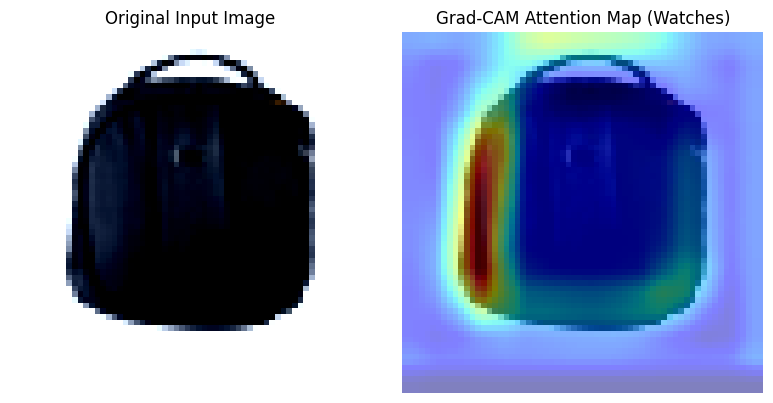

[SUCCESS] Grad-CAM figure exported safely before archiving.


In [10]:
# =====================================================================
# CELL 7: EXPLAINABLE AI (GRAD-CAM) ATTENTION VISUALIZATION
# =====================================================================
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture forward activations and backward gradients
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
        
    def generate_heatmap(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        loss = output[0, class_idx]
        loss.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
            
        cam = np.maximum(cam, 0) # Apply ReLU
        cam = torch.nn.functional.interpolate(
            torch.tensor(cam).unsqueeze(0).unsqueeze(0), size=(64, 64), mode='bilinear'
        ).squeeze().numpy()
        
        cam = cam - np.min(cam)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        return cam

# Hook into the last conv layer of your custom architecture feature stack
target_layer_block = custom_model.features[-3] 
cam_extractor = GradCAM(custom_model, target_layer_block)

# Extract a sample image from the test loader
sample_images, sample_labels = next(iter(test_loader))
sample_input = sample_images[0].unsqueeze(0).to(device)
pred_class = torch.argmax(custom_model(sample_input), dim=1).item()

# Generate the activation grid
heatmap_output = cam_extractor.generate_heatmap(sample_input, pred_class)

# Plot and save the Explainable AI figure
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Reverse the normalisation layer scaling just for visual display
img_display = sample_images[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
img_display = np.clip(img_display, 0, 1)

axes[0].imshow(img_display)
axes[0].set_title("Original Input Image")
axes[0].axis('off')

axes[1].imshow(img_display)
axes[1].imshow(heatmap_output, cmap='jet', alpha=0.5)
axes[1].set_title(f"Grad-CAM Attention Map ({target_classes[pred_class]})")
axes[1].axis('off')

plt.tight_layout()
# Save as high-res PDF to fulfill the Explainable AI report requirement
plt.savefig('explainable_ai_gradcam_output.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print("[SUCCESS] Grad-CAM figure exported safely before archiving.")

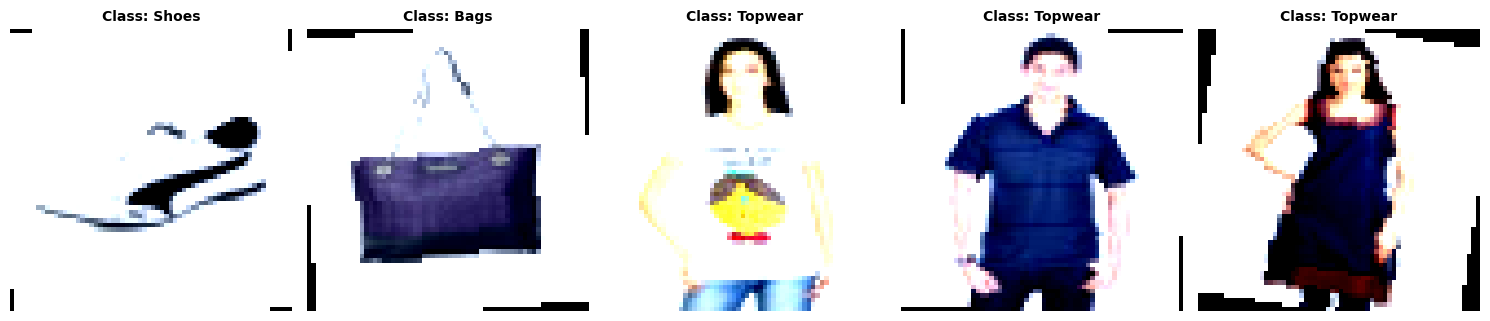

✅ dataset_samples_grid.pdf saved for Section 3.2.5


In [12]:
# =====================================================================
# EXTRA CODES: GENERATE DATASET GRAPHICAL SAMPLE GRID
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

for i in range(5):
    # Un-normalize back to [0,1] display range
    img_display = images[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    img_display = np.clip(img_display, 0, 1)
    
    axes[i].imshow(img_display)
    axes[i].set_title(f"Class: {target_classes[labels[i].item()]}", fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples_grid.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✅ dataset_samples_grid.pdf saved for Section 3.2.5")

In [13]:
# =====================================================================
# EXTRA CODES: COMPUTE STRUCTURAL COMPLEXITY PROFILE
# =====================================================================
import time

def profile_architecture(model, sample_input_shape=(1, 3, 64, 64)):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    
    # Calculate disk footprint size in Megabytes
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    # Compute basic CPU/GPU execution speed benchmark
    dummy_input = torch.randn(*sample_input_shape).to(device)
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_input)
    avg_inference_ms = ((time.time() - start_time) / 100) * 1000
    
    return {
        "Total Params": total_params,
        "Trainable Params": trainable_params,
        "Frozen Params": frozen_params,
        "Size (MB)": size_mb,
        "Inference Latency (ms)": avg_inference_ms
    }

print("=== CUSTOM CNN ARCHITECTURE FOOTPRINT ===")
custom_profile = profile_architecture(custom_model)
for k, v in custom_profile.items(): print(f" - {k}: {v:,.2f}" if isinstance(v, float) else f" - {k}: {v:,}")

print("\n=== MOBILENETV3 BASELINE ARCHITECTURE FOOTPRINT ===")
transfer_profile = profile_architecture(transfer_model)
for k, v in transfer_profile.items(): print(f" - {k}: {v:,.2f}" if isinstance(v, float) else f" - {k}: {v:,}")

=== CUSTOM CNN ARCHITECTURE FOOTPRINT ===
 - Total Params: 32,549
 - Trainable Params: 32,549
 - Frozen Params: 0
 - Size (MB): 0.12
 - Inference Latency (ms): 1.27

=== MOBILENETV3 BASELINE ARCHITECTURE FOOTPRINT ===
 - Total Params: 1,001,509
 - Trainable Params: 74,501
 - Frozen Params: 927,008
 - Size (MB): 3.87
 - Inference Latency (ms): 6.61


In [14]:
# =====================================================================
# SAVE ALL OUTPUTS INTO ZIP FILE
# =====================================================================
import os, zipfile
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# --------------------------------------------------
# Save CSVs
# --------------------------------------------------
try:
    pd.DataFrame(
        classification_report(
            y_true, custom_preds,
            target_names=target_classes,
            output_dict=True
        )
    ).transpose().to_csv('classification_report_cnn.csv')
    print("✅ classification_report_cnn.csv saved")
except Exception as e:
    print(f"❌ CNN report failed: {e}")

try:
    pd.DataFrame(
        classification_report(
            y_true, transfer_preds,
            target_names=target_classes,
            output_dict=True
        )
    ).transpose().to_csv('classification_report_mobilenet.csv')
    print("✅ classification_report_mobilenet.csv saved")
except Exception as e:
    print(f"❌ MobileNet report failed: {e}")

try:
    pd.DataFrame({
        'Model'            : ['Custom CNN', 'MobileNetV3'],
        'Test Accuracy (%)': [
            round(accuracy_score(y_true, custom_preds) * 100, 2),
            round(accuracy_score(y_true, transfer_preds) * 100, 2)
        ]
    }).to_csv('model_comparison.csv', index=False)
    print("✅ model_comparison.csv saved")
except Exception as e:
    print(f"❌ Comparison table failed: {e}")

# --------------------------------------------------
# Zip all output files
# --------------------------------------------------
extensions = ('.png', '.pdf', '.csv', '.pth')
found, missing_expected = [], []

# UPDATED: Explicitly tracking the new required report figures
expected = [
    'class_distribution.png',
    'dataset_samples_grid.pdf',
    'learning_curves.pdf',
    'confusion_matrices_comparison.pdf',
    'explainable_ai_gradcam_output.pdf',
    'classification_report_cnn.csv',
    'classification_report_mobilenet.csv',
    'model_comparison.csv',
    'custom_fashion_cnn.pth',
    'mobilenetv3_fashion.pth'
]

all_files = [f for f in os.listdir('.') if f.endswith(extensions)]

with zipfile.ZipFile('Pattern_Recognition_Project_Output.zip', 'w') as zipf:
    for f in all_files:
        zipf.write(f)
        found.append(f)

for f in expected:
    if f not in found:
        missing_expected.append(f)

print("\n=== ZIP SUMMARY ===")
print(f"✅ Files zipped ({len(found)}):")
for f in found:    print(f"   + {f}")
if missing_expected:
    print(f"\n❌ Expected but missing:")
    for f in missing_expected: print(f"   - {f}")
print(f"\nZIP → Pattern_Recognition_Project_Output.zip")

✅ classification_report_cnn.csv saved
✅ classification_report_mobilenet.csv saved
✅ model_comparison.csv saved

=== ZIP SUMMARY ===
✅ Files zipped (10):
   + custom_fashion_cnn.pth
   + model_comparison.csv
   + confusion_matrices_comparison.pdf
   + classification_report_mobilenet.csv
   + learning_curves.pdf
   + classification_report_cnn.csv
   + explainable_ai_gradcam_output.pdf
   + mobilenetv3_fashion.pth
   + class_distribution.png
   + dataset_samples_grid.pdf

ZIP → Pattern_Recognition_Project_Output.zip
